# BayesPrism reference demo

Semi-synthetic counts derived from 128 genes in the bundled single-cell reference. The short Gibbs chain (24 iterations, burn-in 12) is an execution demonstration, NOT a converged biological estimate. Production analyses need adequate chains, convergence assessment and a relevant reference.

Run from the `tutorials` directory in the prepared iobrx environment. Outputs are written to `extension-work/`; the figure uses a display-only feature z-score. No input values are normalized for the analysis unless the visible API parameters request it.

In [1]:
from pathlib import Path
from time import perf_counter
from contextlib import redirect_stdout, redirect_stderr
import io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iobrx
from _common import load, tpm_input, configure, runtime_info
from _extension_figures import plot_result

iobrx.set_threads(2)
slug = '23_bayesprism'
work = Path("extension-work") / slug
work.mkdir(parents=True, exist_ok=True)
print(json.dumps(runtime_info(), indent=2))
groups = None
configure()


{
  "iobrx": "0.3.0",
  "threads": 2,
  "native_available": true,
  "native_reason": null,
  "sorting": "numpy CPU dispatch",
  "requires_avx512": false,
  "bundled_openblas_found": true,
  "versions": {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.7.2",
    "iobrpy": "0.2.1",
    "gseapy": "1.3.1",
    "matplotlib": "3.11.1"
  }
}


In [2]:
from importlib.resources import files
reference = files("iobrpy.bayesprism.BP_data")
columns = pd.read_csv(str(reference.joinpath("sc_dat.csv")), nrows=0).columns[:129]
sc = pd.read_csv(str(reference.joinpath("sc_dat.csv")), usecols=list(columns), index_col=0)
types = pd.read_csv(str(reference.joinpath("cell_type_labels.csv")), header=None).iloc[:, 0].tolist()
states = pd.read_csv(str(reference.joinpath("cell_state_labels.csv")), header=None).iloc[:, 0].tolist()
rng = np.random.default_rng(42)
rates = sc.mean().to_numpy() * 20 + 1
data = pd.DataFrame(rng.poisson(rates[:, None], size=(len(rates), 3)), index=sc.columns, columns=["Demo1", "Demo2", "Demo3"])

In [3]:
# Capture upstream progress messages; the computation remains the public API call below.
started = perf_counter()
with warnings.catch_warnings(record=True) as diagnostics, redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    result = iobrx.bayesprism(data, sc_dat=sc, cell_type_labels=types, cell_state_labels=states, n_threads=2, state_order="sorted", gibbs_control={"chain.length": 24, "burn.in": 12, "thinning": 2})
elapsed = perf_counter() - started
for warning in diagnostics:
    print(f"{warning.category.__name__}: {warning.message}")
plot = result["theta"]
tables = result if isinstance(result, dict) else {"result": result}
for name, table in tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(work / (name + ".csv"))
plot.to_csv(work / "display_source.csv")
timing = {"analysis": slug, "input_shape": list(data.shape), "seconds": elapsed, "threads": 2, "scope": "one API call; excludes input preparation", "fixture": 'Semi-synthetic counts derived from 128 genes in the bundled single-cell reference. The short Gibbs chain (24 iterations, burn-in 12) is an execution demonstration, NOT a converged biological estimate. Production analyses need adequate chains, convergence assessment and a relevant reference.'}
Path("results").mkdir(exist_ok=True)
Path("results", slug + "_timing.json").write_text(json.dumps(timing, indent=2) + "\n")
print(json.dumps(timing, indent=2))
display(plot.head())

{
  "analysis": "23_bayesprism",
  "input_shape": [
    128,
    3
  ],
  "seconds": 0.3513125269964803,
  "threads": 2,
  "scope": "one API call; excludes input preparation",
  "fixture": "Semi-synthetic counts derived from 128 genes in the bundled single-cell reference. The short Gibbs chain (24 iterations, burn-in 12) is an execution demonstration, NOT a converged biological estimate. Production analyses need adequate chains, convergence assessment and a relevant reference."
}


,Malignant_cells_BayesPrism,T_lymphocytes_BayesPrism,Myeloid_cells_BayesPrism,B_lymphocytes_BayesPrism,Fibroblasts_BayesPrism,NK_cells_BayesPrism,Endothelial_cells_BayesPrism,Epithelial_cells_BayesPrism,MAST_cells_BayesPrism
Demo1,0.258870,0.024559,0.086240,0.097162,0.205836,0.058047,0.089313,0.132350,0.047623
Demo2,0.221768,0.144640,0.075032,0.151612,0.121838,0.038925,0.091886,0.133861,0.020438
Demo3,0.147034,0.127679,0.211384,0.013252,0.133311,0.035216,0.054621,0.253911,0.023594


findfont: Failed to find font weight medium, now using 400.


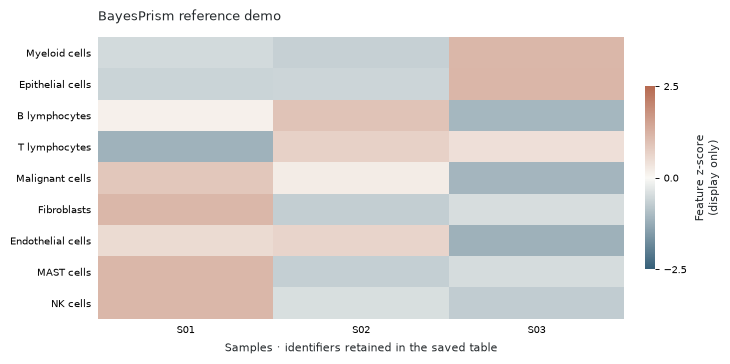

In [4]:
configure(2)
fig = plot_result(plot, 'BayesPrism reference demo', 2, groups=groups)
for extension in ('png', 'pdf', 'svg'):
    fig.savefig(Path('figures') / (slug + '.' + extension), dpi=200, bbox_inches='tight')
review = Path('review/extensions')
review.mkdir(parents=True, exist_ok=True)
fig.savefig(review / (slug + '-round-2.png'), dpi=120, bbox_inches='tight')
plt.show()

Interpretation: the heatmap highlights relative patterns within each displayed feature. Colors are not cell fractions, statistical significance or cross-feature effect sizes. Full numeric outputs are saved separately. Runtime depends on hardware, input size, parameters and cache state.